# Vectorless RAG


**PageIndex** is a new kind of document AI that works like a human expert. Instead of breaking your PDF into chunks and doing keyword search, it builds a **reasoning tree** (like a smart table of contents) and uses an LLM to *navigate* it — just like how you'd skim a book's index to find an answer.

## 📋 Prerequisites

| Service | Free Tier | Sign Up |
|---------|-----------|--------|
| Neo4j AuraDB | 1 free instance (512MB) | https://console.neo4j.io |
| Groq Cloud | 14,400 req/day free | https://console.groq.com |
|PageIndex | 200 pages free |https://dash.pageindex.ai/api-keys|


## Method 1: Whoosh → keyword (BM25-style) retrieval

### Step 1: Install Required Libraries

In [14]:
!pip install -q --upgrade groq whoosh pypdf

### Step 2: Import required Libraries + Config

In [15]:
import os
from groq import Groq
from whoosh.index import create_in
from whoosh.fields import Schema, TEXT
from whoosh.qparser import QueryParser,MultifieldParser, OrGroup
from pypdf import PdfReader
from google.colab import userdata

GROQ_API_KEY = userdata.get("GROQ_API_KEY")
PDF_PATH = "/content/HR Policy Manual 2025.pdf"
INDEX_DIR = "indexdir"

### Step 3: supporting Function

In [17]:
# ---------------------------
#  Chunking
# ---------------------------
def chunk_text(text, chunk_size=500):
    sentences = text.split(". ")
    chunks = []
    current = ""

    for s in sentences:
        if len(current) + len(s) < chunk_size:
            current += s + ". "
        else:
            chunks.append(current)
            current = s + ". "

    if current:
        chunks.append(current)

    return chunks

# ---------------------------
#  LOAD PDF
# ---------------------------
def load_pdf(path):
    reader = PdfReader(path)
    text_chunks = []

    for page in reader.pages:
        text = page.extract_text()
        if text:
            # simple chunking
            chunks = chunk_text(text)
            text_chunks.extend(chunks)

    return text_chunks

# ---------------------------
# CREATE WHOOSH INDEX
# ---------------------------
def create_index(chunks):
    if not os.path.exists(INDEX_DIR):
        os.mkdir(INDEX_DIR)

    schema = Schema(content=TEXT(stored=True))
    ix = create_in(INDEX_DIR, schema)

    writer = ix.writer()
    for chunk in chunks:
        writer.add_document(content=chunk)
    writer.commit()

    return ix

# ---------------------------
# SEARCH (BM25)
# ---------------------------
def search(ix, query, top_k=3):
    with ix.searcher() as searcher:
        parser = QueryParser("content", ix.schema,group=OrGroup)

        query = query.lower().replace("?", "").replace("what is", "").strip()

        q = parser.parse(query)
        results = searcher.search(q, limit=top_k)

        return [r["content"] for r in results]

# ---------------------------
# CALL GROQ LLM
# ---------------------------
def ask_llm(context, question):
    client = Groq(api_key=GROQ_API_KEY)

    prompt = f"""
              You are an assistant answering questions from a document.

              Context:
              {context}

              Question:
              {question}

              Answer clearly using only the context.
              """

    response = client.chat.completions.create(
        model="openai/gpt-oss-120b",
        messages=[{"role": "user", "content": prompt}],
        temperature=0
    )

    return response.choices[0].message.content.strip()

### Step 4: Build Index

In [18]:
print("Loading PDF...")
chunks = load_pdf(PDF_PATH)

print("Creating index...")
ix = create_index(chunks)
print("Ready!!")

Loading PDF...
Creating index...
Ready!!


### Step 5: Ask Questions

In [21]:

while True:
    query = input("\nAsk a question (or 'exit'): ")
    if query.lower() == "exit":
        break

    results = search(ix, query)
    context = "\n\n".join(results)

    answer = ask_llm(context, query)
    print("\nAnswer:\n", answer)


Ask a question (or 'exit'): what is grace period given to each employee?

Answer:
 The grace period given to each employee is **fifteen minutes**.

Ask a question (or 'exit'): exit


## Method 2: Using PageIndex API

### Step 1: Install PageIndex

In [22]:
!pip install -q --upgrade pageindex

### Step 2: Import required Libraries + Config

In [30]:
import os
from pageindex import PageIndexClient
import pageindex.utils as utils
from dotenv import load_dotenv
from google.colab import userdata
from groq import AsyncGroq
import time
import json

load_dotenv()

PAGEINDEX_API_KEY = userdata.get("PAGEINDEX_API_KEY")
pi_client = PageIndexClient(api_key=PAGEINDEX_API_KEY)
GROQ_API_KEY = userdata.get("GROQ_API_KEY")

### Step 3: Set Up the LLM

In [32]:
async def call_llm(prompt, model="openai/gpt-oss-120b", temperature=0):
    client = AsyncGroq(api_key=GROQ_API_KEY)

    response = await client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=temperature
    )

    return response.choices[0].message.content.strip()

### Step 4: Upload Your PDF

In [27]:
pdf_path = "/content/AbhishekJanjal.pdf"

doc_id = pi_client.submit_document(pdf_path)["doc_id"]
print('Document Submitted:', doc_id)


Document Submitted: pi-cmn1im3z001k90gpkatrmn0l0


### Step 5: Wait for Processing & Retrieve the Document Tree

In [28]:
print("Waiting for document to be processed...")
while not pi_client.is_retrieval_ready(doc_id):
    print("Still processing... retrying in 10 seconds")
    time.sleep(10)

tree = pi_client.get_tree(doc_id, node_summary=True)['result']
print('Simplified Tree Structure of the Document:')
utils.print_tree(tree)

Waiting for document to be processed...
Simplified Tree Structure of the Document:
[{'title': 'OBJECTIVE',
  'node_id': '0000',
  'summary': '# OBJECTIVE\n\nAI/ML Engineer with experie...'},
 {'title': 'EDUCATION',
  'node_id': '0001',
  'summary': '# EDUCATION\n\n|  Master of Applied Mathem...'},
 {'title': 'SKILLS', 'node_id': '0002', 'summary': '# SKILLS\n\n|  Technical Skills | Python, ...'},
 {'title': 'EXPERIENCE',
  'node_id': '0003',
  'summary': 'The text details professional experience...'}]


### Step 6: Search the Document Tree with an LLM

In [34]:
query = "What are the key Skills outlined in this document?"

tree_without_text = utils.remove_fields(tree.copy(), fields=['text'])

search_prompt = f"""
You are given a question and a tree structure of a document.
Each node contains a node id, node title, and a corresponding summary.
Your task is to find all nodes that are likely to contain the answer to the question.

Question: {query}

Document tree structure:
{json.dumps(tree_without_text, indent=2)}

Please reply in the following JSON format:
{{
    "thinking": "<Your thinking process on which nodes are relevant to the question>",
    "node_list": ["node_id_1", "node_id_2", ..., "node_id_n"]
}}
Directly return the final JSON structure. Do not output anything else.
"""

tree_search_result = await call_llm(search_prompt)
print(tree_search_result)

{
    "thinking": "The question asks for the key Skills outlined in the document. The node titled 'SKILLS' (node_id 0002) contains a detailed list of technical skills, AI/ML libraries, generative AI tools, frameworks, cloud platforms, and data visualization tools, which directly answers the query. While the OBJECTIVE node also mentions some skills, the comprehensive enumeration is in the SKILLS node, making it the most relevant.",
    "node_list": ["0002"]
}


### Step 7: Review the Retrieved Nodes

In [35]:
node_map = utils.create_node_mapping(tree)
tree_search_result_json = json.loads(tree_search_result)

print('Reasoning Process:')
utils.print_wrapped(tree_search_result_json['thinking'])

print('\nRetrieved Nodes:')
for node_id in tree_search_result_json["node_list"]:
    node = node_map[node_id]
    print(f"Node ID: {node['node_id']}\t Page: {node['page_index']}\t Title: {node['title']}")

Reasoning Process:
The question asks for the key Skills outlined in the document. The node titled 'SKILLS' (node_id
0002) contains a detailed list of technical skills, AI/ML libraries, generative AI tools,
frameworks, cloud platforms, and data visualization tools, which directly answers the query. While
the OBJECTIVE node also mentions some skills, the comprehensive enumeration is in the SKILLS node,
making it the most relevant.

Retrieved Nodes:
Node ID: 0002	 Page: 1	 Title: SKILLS


### Step 8: Generate the Final Answer

In [36]:
node_list = tree_search_result_json["node_list"]
relevant_content = "\n\n".join(node_map[node_id]["text"] for node_id in node_list)

print('Retrieved Context:\n')
utils.print_wrapped(relevant_content[:1000] + '...')

answer_prompt = f"""
Answer the question based on the context:

Question: {query}
Context: {relevant_content}

Provide a clear, concise answer based only on the context provided.
"""

print('Generated Answer:\n')
answer = await call_llm(answer_prompt)
utils.print_wrapped(answer)

Retrieved Context:

# SKILLS

|  Technical Skills | Python, C++, SQL  |
| --- | --- |
|  AI/ML Libraries | Pandas, NumPy, Scikit-learn, PyTorch, TensorFlow, Keras, Transformers, spaCy  |
|  Generative AI | LangChain,RAG, Prompt Engineering, LLaMA, Zephyr-7B, Gemini  |
|  Frameworks & Tools | FastAPI, Flask, Streamlit, Docker, MLflow, Git, Jupyter, VS Code, PyCharm  |
|  Cloud Platforms | AWS, GCP  |
|  Data Visualization | Matplotlib, Seaborn, Tableau  |
...
Generated Answer:

The document highlights the following key skills:

- **Technical Skills:** Python, C++, SQL
- **AI/ML Libraries:** Pandas, NumPy, Scikit‑learn, PyTorch, TensorFlow, Keras, Transformers, spaCy
- **Generative AI:** LangChain, RAG, Prompt Engineering, LLaMA, Zephyr‑7B, Gemini
- **Frameworks & Tools:** FastAPI, Flask, Streamlit, Docker, MLflow, Git, Jupyter, VS Code, PyCharm
- **Cloud Platforms:** AWS, GCP
- **Data Visualization:** Matplotlib, Seaborn, Tableau


In [37]:
async def ask(query):
    tree_without_text = utils.remove_fields(tree.copy(), fields=['text'])

    search_prompt = f"""
You are given a question and a tree structure of a document.
Each node contains a node id, node title, and a corresponding summary.
Your task is to find all nodes that are likely to contain the answer to the question.

Question: {query}

Document tree structure:
{json.dumps(tree_without_text, indent=2)}

Please reply in the following JSON format:
{{
    "thinking": "<Your thinking process on which nodes are relevant to the question>",
    "node_list": ["node_id_1", "node_id_2", ..., "node_id_n"]
}}
Directly return the final JSON structure. Do not output anything else.
"""

    search_result = await call_llm(search_prompt)
    search_result_json = json.loads(search_result)

    node_list = search_result_json["node_list"]
    relevant_content = "\n\n".join(node_map[node_id]["text"] for node_id in node_list)
    answer_prompt = f"""
Answer the question based on the context:

Question: {query}
Context: {relevant_content}

Provide a clear, concise answer based only on the context provided.
"""

    answer = await call_llm(answer_prompt)

    print(f"Query: {query}")
    print(f"\nRelevant Nodes: {node_list}")
    print("\nAnswer:")
    utils.print_wrapped(answer)
    print("-" * 60)

# --- Enter your query below and run this cell ---
user_query = input("Enter your query: ")
await ask(user_query)

Enter your query: in which year abhishek completed is Bsc in mathematics?
Query: in which year abhishek completed is Bsc in mathematics?

Relevant Nodes: ['0001']

Answer:
Abhishek completed his B.Sc. in Mathematics in **2022**.
------------------------------------------------------------


## Method 3: Graph RAG

### Step 1: Install Dependencies

In [60]:
!pip install neo4j langchain langchain-groq langchain-community groq pdfplumber pypdf networkx matplotlib -q --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.1/68.1 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 47.2 MB/s eta 0:00:00


### Step 2: Import required Libraries + Config

In [75]:
import os
from google.colab import userdata
from neo4j import GraphDatabase
from langchain_groq import ChatGroq
import pandas as pd
from langchain_core.prompts import ChatPromptTemplate
import re
from langchain_community.graphs import Neo4jGraph
from langchain_community.chains.graph_qa.cypher import GraphCypherQAChain
import json
import networkx as nx, matplotlib.pyplot as plt, matplotlib.patches as mpatches

NEO4J_URI      = userdata.get('NEO4J_URI')
NEO4J_USERNAME = userdata.get('NEO4J_USERNAME')
NEO4J_PASSWORD = userdata.get('NEO4J_PASSWORD')
GROQ_API_KEY   = userdata.get('GROQ_API_KEY')

### Step 3: Upload Your PDF

In [64]:
from google.colab import files
import pdfplumber, io

print('Click the upload button to choose your PDF')
uploaded = files.upload()

PDF_FILENAME = list(uploaded.keys())[0]
PDF_BYTES    = uploaded[PDF_FILENAME]
print(f'Loaded: {PDF_FILENAME} ({len(PDF_BYTES):,} bytes)')

with pdfplumber.open(io.BytesIO(PDF_BYTES)) as pdf:
    TOTAL_PAGES = len(pdf.pages)
    preview = pdf.pages[0].extract_text() or ''

print(f'Total pages: {TOTAL_PAGES}')
print('--- First page preview ---')
print(preview[:600])


Click the upload button to choose your PDF


Saving HR Policy Manual 2025.pdf to HR Policy Manual 2025 (1).pdf
Loaded: HR Policy Manual 2025 (1).pdf (6,492,871 bytes)
Total pages: 209
--- First page preview ---
HUMAN RESOURCES
POLICY MANUAL 2025
STAFF
www.iima.ac.in


### Step 4: Connect Neo4j + Groq

In [65]:
from neo4j import GraphDatabase
from langchain_groq import ChatGroq

driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USERNAME, NEO4J_PASSWORD))
with driver.session() as s:
    print(s.run("RETURN 'Neo4j connected' AS msg").single()['msg'])

# Auto-detect database name (AuraDB Free uses random hex IDs like '7d474826')
try:
    with driver.session(database='system') as s:
        rows = s.run('SHOW DATABASES YIELD name, type RETURN name, type').data()
        print('All databases:', rows)
        DB_NAME = next((r['name'] for r in rows
                        if r['name'] != 'system' and r.get('type') == 'standard'), None)
        print(f'Using database: {DB_NAME!r}')
except Exception as e:
    DB_NAME = None
    print(f'DB auto-detect failed ({e}), using driver default')

llm = ChatGroq(model='llama-3.3-70b-versatile', temperature=0, groq_api_key=GROQ_API_KEY)
resp = llm.invoke('Reply in 5 words: you are ready')
print('Groq:', resp.content)


Neo4j connected
All databases: [{'name': '7d474826', 'type': 'standard'}, {'name': 'system', 'type': 'system'}, {'name': 'system', 'type': 'system'}, {'name': 'system', 'type': 'system'}]
Using database: '7d474826'
Groq: I am completely ready now


###Step 5: Clear DB & Create Constraints

**Graph schema for HR Policy PDFs:**

| Node | Properties |
|------|-----------|
| `Chapter` | number, title |
| `Policy` | name, description |
| `EmployeeGroup` | name |
| `LeaveType` | name, days, description |
| `Benefit` | name, type, description |
| `Role` | title |

**Relationships:** `CONTAINS`, `GOVERNS`, `APPLIES_TO`, `PROVIDES`

In [66]:
with driver.session(database=DB_NAME) as s:
    s.run('MATCH (n) DETACH DELETE n')
    print('Cleared existing nodes')

constraints = [
    'CREATE CONSTRAINT IF NOT EXISTS FOR (c:Chapter)       REQUIRE c.title IS UNIQUE',
    'CREATE CONSTRAINT IF NOT EXISTS FOR (p:Policy)        REQUIRE p.name  IS UNIQUE',
    'CREATE CONSTRAINT IF NOT EXISTS FOR (e:EmployeeGroup) REQUIRE e.name  IS UNIQUE',
    'CREATE CONSTRAINT IF NOT EXISTS FOR (l:LeaveType)     REQUIRE l.name  IS UNIQUE',
    'CREATE CONSTRAINT IF NOT EXISTS FOR (b:Benefit)       REQUIRE b.name  IS UNIQUE',
    'CREATE CONSTRAINT IF NOT EXISTS FOR (r:Role)          REQUIRE r.title IS UNIQUE',
]
with driver.session(database=DB_NAME) as s:
    for cq in constraints:
        s.run(cq)
print('Constraints created')


Cleared existing nodes
Constraints created


### Step 6: Define Entity Extraction Prompt

In [67]:
import json, re, time
from langchain_core.prompts import ChatPromptTemplate

# NOTE: {{ }} are escaped literal braces for LangChain templates
EXTRACT_PROMPT = ChatPromptTemplate.from_messages([
    ('system', '''You are an HR policy analyst. Extract structured entities from the HR policy text.
Return ONLY valid JSON — no markdown, no backticks, no explanation.

Required JSON structure (use empty list [] if nothing found):
{{
  "chapters":        [{{"number": "3", "title": "Recruitment Policy"}}],
  "policies":        [{{"name": "Manpower Requisition", "description": "Process to raise hiring needs", "chapter": "Recruitment Policy"}}],
  "employee_groups": [{{"name": "Group A"}}],
  "leave_types":     [{{"name": "Casual Leave", "days": "8 per year", "description": "Short personal leave"}}],
  "benefits":        [{{"name": "Group Mediclaim", "type": "Insurance", "description": "Medical insurance for staff"}}],
  "roles":           [{{"title": "Director"}}]
}}

Rules: only include entities clearly in the text. Keep descriptions under 20 words.'''),
    ('human', '{text}')
])

extract_chain = EXTRACT_PROMPT | llm

def extract_entities(text):
    raw = extract_chain.invoke({'text': text}).content
    raw_clean = re.sub(r'```(?:json)?\n?', '', raw).strip().rstrip('`')
    try:
        return json.loads(raw_clean)
    except json.JSONDecodeError:
        m = re.search(r'\{.*\}', raw_clean, re.DOTALL)
        if m:
            return json.loads(m.group())
        print(f'JSON parse failed. Raw snippet: {raw_clean[:200]}')
        return {}

def pdf_to_chunks(pdf_bytes, pages_per_chunk=3):
    chunks = []
    with pdfplumber.open(io.BytesIO(pdf_bytes)) as pdf:
        for i in range(0, len(pdf.pages), pages_per_chunk):
            batch = pdf.pages[i:i+pages_per_chunk]
            text  = '\n'.join(p.extract_text() or '' for p in batch).strip()
            if text:
                chunks.append({'pages': f'{i+1}-{i+len(batch)}', 'text': text})
    return chunks

print('Extraction functions ready')


Extraction functions ready


### Step 7: Run Extraction (Chunk by Chunk)

In [68]:
PAGES_PER_CHUNK = 4      # pages per Groq call
MAX_CHUNK_CHARS = 6000   # truncate to stay within token limits
DELAY_SECONDS   = 1.5    # rate-limit safety pause
MAX_PAGES       = 80     # set None to process all pages

all_chunks = pdf_to_chunks(PDF_BYTES, PAGES_PER_CHUNK)
if MAX_PAGES:
    all_chunks = [c for c in all_chunks if int(c['pages'].split('-')[0]) <= MAX_PAGES]

print(f'Processing {len(all_chunks)} chunks ({PAGES_PER_CHUNK} pages each)\n')

aggregated = {'chapters':[],'policies':[],'employee_groups':[],'leave_types':[],'benefits':[],'roles':[]}

for idx, chunk in enumerate(all_chunks):
    print(f'  [{idx+1}/{len(all_chunks)}] Pages {chunk["pages"]} ...', end=' ')
    try:
        data = extract_entities(chunk['text'][:MAX_CHUNK_CHARS])
        for key in aggregated:
            aggregated[key].extend(data.get(key, []))
        counts = {k: len(v) for k, v in data.items() if v}
        print(f'OK {counts}')
    except Exception as e:
        print(f'ERROR: {e}')
    time.sleep(DELAY_SECONDS)

# De-duplicate
def dedup(items, key):
    seen, out = set(), []
    for item in items:
        v = item.get(key, '')
        if v and v not in seen:
            seen.add(v); out.append(item)
    return out

aggregated['chapters']        = dedup(aggregated['chapters'],        'title')
aggregated['policies']        = dedup(aggregated['policies'],        'name')
aggregated['employee_groups'] = dedup(aggregated['employee_groups'], 'name')
aggregated['leave_types']     = dedup(aggregated['leave_types'],     'name')
aggregated['benefits']        = dedup(aggregated['benefits'],        'name')
aggregated['roles']           = dedup(aggregated['roles'],           'title')

print('\nExtraction complete — unique entities:')
for k, v in aggregated.items():
    print(f'  {k:20s}: {len(v)}')


Processing 20 chunks (4 pages each)

  [1/20] Pages 1-4 ... OK {'roles': 1}
  [2/20] Pages 5-8 ... OK {'chapters': 5, 'policies': 1, 'roles': 1}
  [3/20] Pages 9-12 ... OK {'chapters': 7, 'policies': 5, 'employee_groups': 2, 'benefits': 4, 'roles': 1}
  [4/20] Pages 13-16 ... OK {'roles': 13}
  [5/20] Pages 17-20 ... OK {'chapters': 2, 'policies': 1, 'employee_groups': 2, 'roles': 7}
  [6/20] Pages 21-24 ... OK {'chapters': 6, 'policies': 4, 'employee_groups': 3, 'roles': 11}
  [7/20] Pages 25-28 ... OK {'chapters': 1, 'policies': 1, 'employee_groups': 3, 'leave_types': 1, 'benefits': 2, 'roles': 3}
  [8/20] Pages 29-32 ... OK {'chapters': 8, 'policies': 2, 'leave_types': 1, 'benefits': 1}
  [9/20] Pages 33-36 ... OK {'employee_groups': 4, 'roles': 3}
  [10/20] Pages 37-40 ... OK {'chapters': 1, 'policies': 1, 'employee_groups': 1, 'benefits': 1, 'roles': 2}
  [11/20] Pages 41-44 ... OK {'chapters': 1, 'policies': 4, 'roles': 3}
  [12/20] Pages 45-48 ... OK {'policies': 1, 'employee_gr

### Step 8: Write Entities to Neo4j

In [69]:
def safe_run(session, query, **params):
    try: session.run(query, **params)
    except Exception as e: print(f'  Skip: {e}')

with driver.session(database=DB_NAME) as s:
    for ch in aggregated['chapters']:
        safe_run(s, 'MERGE (c:Chapter {title:$t}) SET c.number=$n',
                 t=ch.get('title',''), n=ch.get('number',''))

    for p in aggregated['policies']:
        safe_run(s, 'MERGE (p:Policy {name:$n}) SET p.description=$d',
                 n=p.get('name',''), d=p.get('description',''))
        if p.get('chapter'):
            safe_run(s, 'MATCH (c:Chapter{title:$c}),(p:Policy{name:$p}) MERGE (c)-[:CONTAINS]->(p)',
                     c=p['chapter'], p=p['name'])

    for eg in aggregated['employee_groups']:
        safe_run(s, 'MERGE (:EmployeeGroup {name:$n})', n=eg.get('name',''))

    for lt in aggregated['leave_types']:
        safe_run(s, 'MERGE (l:LeaveType {name:$n}) SET l.days=$d, l.description=$desc',
                 n=lt.get('name',''), d=lt.get('days',''), desc=lt.get('description',''))
        safe_run(s, 'MATCH (p:Policy),(l:LeaveType{name:$n}) WHERE toLower(p.name) CONTAINS "leave" MERGE (p)-[:GOVERNS]->(l)',
                 n=lt['name'])

    for b in aggregated['benefits']:
        safe_run(s, 'MERGE (b:Benefit {name:$n}) SET b.type=$t, b.description=$d',
                 n=b.get('name',''), t=b.get('type',''), d=b.get('description',''))

    for r in aggregated['roles']:
        safe_run(s, 'MERGE (:Role {title:$t})', t=r.get('title',''))

    # Link policies -> employee groups by name match
    s.run('MATCH (p:Policy),(eg:EmployeeGroup) WHERE toLower(p.description) CONTAINS toLower(eg.name) MERGE (p)-[:APPLIES_TO]->(eg)')

    counts = s.run('MATCH (n) RETURN labels(n)[0] AS label, count(*) AS cnt ORDER BY cnt DESC').data()

print('Graph populated:')
for row in counts:
    print(f'  {row["label"]:20s}: {row["cnt"]} nodes')


Graph populated:
  Chapter             : 50 nodes
  Role                : 47 nodes
  Policy              : 25 nodes
  EmployeeGroup       : 23 nodes
  Benefit             : 10 nodes
  LeaveType           : 9 nodes


### Step 9: Direct Cypher Queries

In [70]:
import pandas as pd

def run_query(cypher):
    with driver.session(database=DB_NAME) as s:
        return pd.DataFrame(s.run(cypher).data())

print('All Chapters:')
display(run_query('MATCH (c:Chapter) RETURN c.number AS No, c.title AS Title ORDER BY c.number'))

print('\nAll Leave Types:')
display(run_query('MATCH (l:LeaveType) RETURN l.name AS Leave, l.days AS Days, l.description AS Description'))

print('\nBenefits:')
display(run_query('MATCH (b:Benefit) RETURN b.name AS Benefit, b.type AS Type LIMIT 15'))

print('\nEmployee Groups:')
display(run_query('MATCH (eg:EmployeeGroup) RETURN eg.name AS Group'))


All Chapters:


,No,Title
0,,DISCIPLINARY PROCEEDINGS
1,1,GENERAL
2,1,MEDICAL EXAMINATION
3,10,Punishment and Compensation
4,13,Protection Against Victimization
5,14,Where Sexual Harassment Amounts to Criminal Of...
6,15,Responsibilities of IIMA
7,16,What IIMA Expects From You
8,18,STAFF EVALUATION AND DEVELOPMENT COMMITTEE
9,19,OFFICERS’ EVALUATION AND DEVELOPMENT COMMITTEE



All Leave Types:


,Leave,Days,Description
0,LTC,,Leave travel concession
1,Leave to the aggrieved,up to three months,Full protection of status and benefits
2,Casual Leave,8 per year,Short personal leave
3,Earned Leave,30 days,Annual leave
4,Commutated Leave,60 days,Leave due to medical reason
5,Extraordinary Leave,1 year,Leave on personal ground
6,Maternity Leave,180 days,Leave for female employees
7,Paternity Leave,15 days,Leave for male employees
8,Child Adoption Leave,180 days,Leave for female employees on adoption



Benefits:


,Benefit,Type
0,Superannuation Benefits,Retirement
1,Contributory Provident Fund,Savings
2,Gratuity,Retirement
3,National Pension System,Retirement
4,House Rent Allowance,Allowance
5,Dearness Allowance,Allowance
6,Medical Expenses Reimbursement,Insurance
7,Protection of status and benefits,Leave benefit
8,Legal Assistance,Support
9,Leave Encashment,Leave



Employee Groups:


,Group
0,Staff
1,Officers
2,Faculty
3,Administrative Staff
4,Group D Staff
5,Administrative Staff in Pay Level 11 and above
6,Administrative Staff in Pay Level 6 to 10
7,Administrative Staff in Pay Level 5 and below
8,Group A
9,Group B


### Step 10: Natural Language Q&A

In [71]:
from langchain_core.prompts import ChatPromptTemplate

SCHEMA_DESC = '''
Node labels: Chapter(title,number), Policy(name,description), EmployeeGroup(name),
             LeaveType(name,days,description), Benefit(name,type,description), Role(title)
Relationships: (Chapter)-[:CONTAINS]->(Policy), (Policy)-[:GOVERNS]->(LeaveType),
               (Policy)-[:APPLIES_TO]->(EmployeeGroup), (Policy)-[:PROVIDES]->(Benefit)
'''

cypher_prompt = ChatPromptTemplate.from_messages([
    ('system', 'You are a Cypher expert for an HR policy graph. Return ONLY raw Cypher, no markdown.\nSchema:{schema}'),
    ('human', '{question}')
])
answer_prompt = ChatPromptTemplate.from_messages([
    ('system', 'You are a helpful HR assistant. Answer using the graph data. Be concise.'),
    ('human', 'Question: {question}\nGraph data: {data}')
])
cypher_chain = cypher_prompt | llm
answer_chain = answer_prompt | llm

def hr_graph_rag(question):
    raw    = cypher_chain.invoke({'schema': SCHEMA_DESC, 'question': question}).content
    cypher = re.sub(r'```(?:cypher)?\n?', '', raw).strip().rstrip('`')
    try:
        with driver.session(database=DB_NAME) as s:
            results = s.run(cypher).data()
    except Exception as e:
        print(f'Cypher error: {e}\nQuery: {cypher}'); return
    snippet = str(results[:3]) + ('...' if len(results) > 3 else '')
    answer  = answer_chain.invoke({'question': question, 'data': str(results) or 'No results.'})
    print(f'Q: {question}')
    print(f'Cypher : {cypher}')
    print(f'Raw    : {snippet}')
    print(f'Answer : {answer.content}')
    print('-' * 60)

hr_graph_rag('How many types of leave are available?')
hr_graph_rag('What insurance benefits are covered?')
hr_graph_rag('Which chapters are in the HR manual?')


Q: How many types of leave are available?
Cypher : MATCH (lt:LeaveType) RETURN COUNT(lt)
Raw    : [{'COUNT(lt)': 9}]
Answer : There are 9 types of leave available.
------------------------------------------------------------


Q: What insurance benefits are covered?
Cypher : MATCH (p:Policy)-[:PROVIDES]->(b:Benefit) 
WHERE b.type = 'insurance' 
RETURN b.name, b.description
Raw    : []
Answer : No insurance benefits are listed.
------------------------------------------------------------
Q: Which chapters are in the HR manual?
Cypher : MATCH (c:Chapter) RETURN c.title, c.number
Raw    : [{'c.title': 'GENERAL', 'c.number': '1'}, {'c.title': 'INTRODUCTION', 'c.number': '2'}, {'c.title': 'RECRUITMENT POLICY', 'c.number': '3'}]...
Answer : The chapters in the HR manual are:

1. GENERAL
2. INTRODUCTION
3. RECRUITMENT POLICY
4. APPOINTMENTS
5. GENERAL CONDUCT, ETHICS & DISCIPLINARY ACTION
6. LEAVE AND ATTENDANCE
7. PERFORMANCE REVIEW
18. STAFF EVALUATION AND DEVELOPMENT COMMITTEE
19. OFFICERS’ EVALUATION AND DEVELOPMENT COMMITTEE
20. ENTERPRISE RESOURCE PLANNING (ERP)
21. GRIEVANCE POLICY
22. RETIREMENT, RESIGNATION ETC. / SUPERANNUATION BENEFITS
23. RETENTION OF DOCUMENTS

Note: Some chapters have similar titles b

### Step 11: LangChain GraphCypherQAChain

In [72]:
graph = Neo4jGraph(url=NEO4J_URI, username=NEO4J_USERNAME, password=NEO4J_PASSWORD, database=DB_NAME)
graph.refresh_schema()

qa_chain = GraphCypherQAChain.from_llm(
    llm=llm, graph=graph, verbose=True,
    return_intermediate_steps=True, allow_dangerous_requests=True
)

response = qa_chain.invoke({'query': 'What leave types are governed by policies?'})
print('Answer:', response['result'])




> Entering new GraphCypherQAChain chain...
Generated Cypher:
MATCH (p:Policy)-[:GOVERNS]->(lt:LeaveType) RETURN lt.name, lt.description, lt.days
Full Context:
[{'lt.name': 'LTC', 'lt.description': 'Leave travel concession', 'lt.days': ''}, {'lt.name': 'LTC', 'lt.description': 'Leave travel concession', 'lt.days': ''}, {'lt.name': 'Leave to the aggrieved', 'lt.description': 'Full protection of status and benefits', 'lt.days': 'up to three months'}, {'lt.name': 'Leave to the aggrieved', 'lt.description': 'Full protection of status and benefits', 'lt.days': 'up to three months'}, {'lt.name': 'Casual Leave', 'lt.description': 'Short personal leave', 'lt.days': '8 per year'}, {'lt.name': 'Casual Leave', 'lt.description': 'Short personal leave', 'lt.days': '8 per year'}, {'lt.name': 'Earned Leave', 'lt.description': 'Annual leave', 'lt.days': '30 days'}, {'lt.name': 'Earned Leave', 'lt.description': 'Annual leave', 'lt.days': '30 days'}, {'lt.name': 'Commutated Leave', 'lt.description': 'L

### Step 12: Analytics Charts

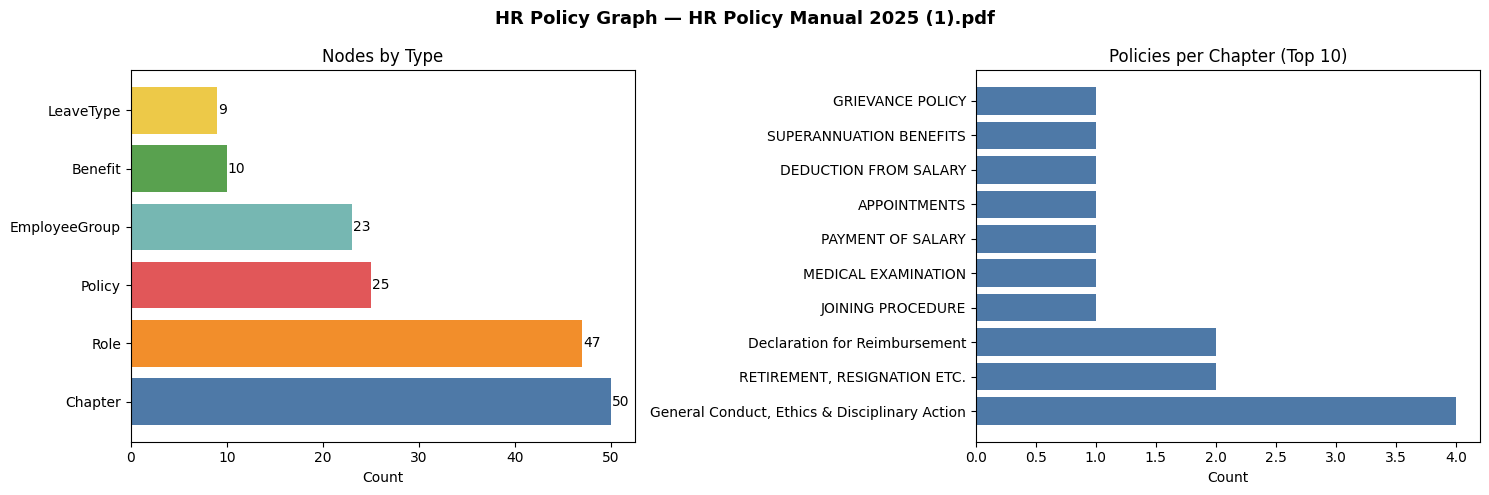

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'HR Policy Graph — {PDF_FILENAME}', fontsize=13, fontweight='bold')

df_nodes = run_query('MATCH (n) RETURN labels(n)[0] AS Label, count(*) AS Count ORDER BY Count DESC')
colors = ['#4e79a7','#f28e2b','#e15759','#76b7b2','#59a14f','#edc948']
axes[0].barh(df_nodes['Label'], df_nodes['Count'], color=colors[:len(df_nodes)])
axes[0].set_title('Nodes by Type'); axes[0].set_xlabel('Count')
for i, v in enumerate(df_nodes['Count']): axes[0].text(v+0.1, i, str(v), va='center')

df_ch = run_query('MATCH (c:Chapter)-[:CONTAINS]->(p:Policy) RETURN c.title AS Chapter, count(p) AS Policies ORDER BY Policies DESC LIMIT 10')
if not df_ch.empty:
    axes[1].barh(df_ch['Chapter'], df_ch['Policies'], color='#4e79a7')
    axes[1].set_title('Policies per Chapter (Top 10)'); axes[1].set_xlabel('Count')
else:
    axes[1].text(0.5, 0.5, 'No Chapter-Policy links found', ha='center', transform=axes[1].transAxes)

plt.tight_layout(); plt.show()

### Step 13: Graph Visualisation

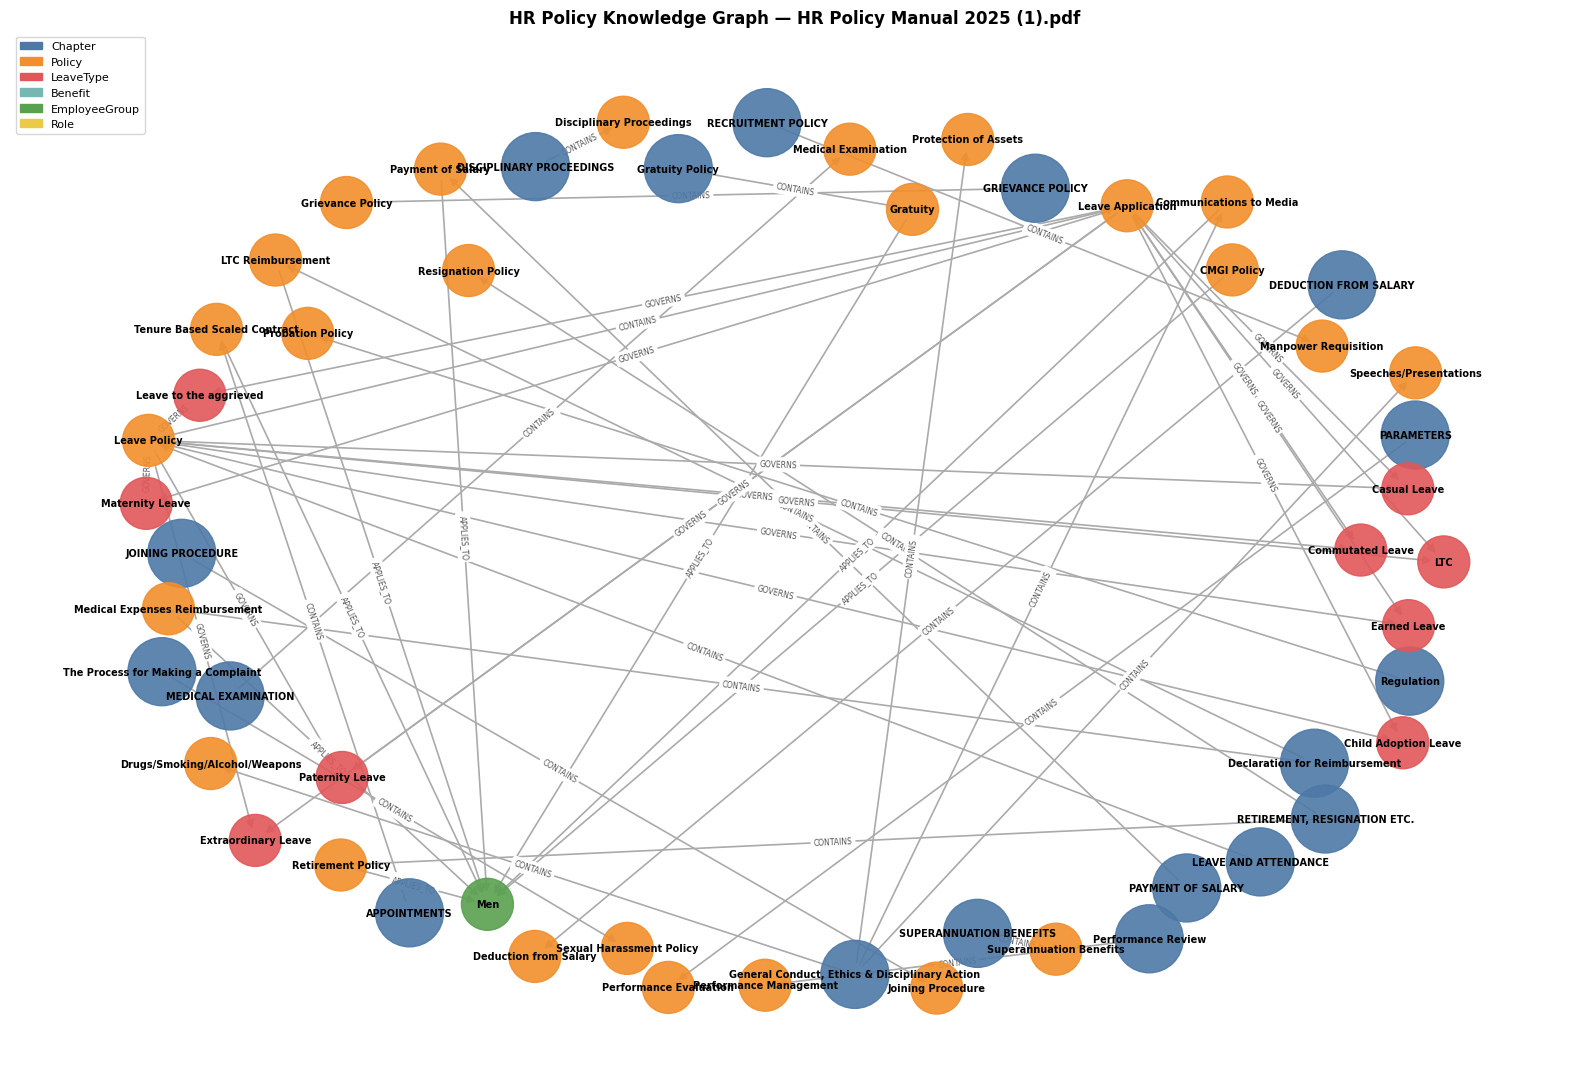

In [74]:
edges_df = run_query("""
    MATCH (a)-[r]->(b)
    RETURN coalesce(a.name,a.title) AS from_node, labels(a)[0] AS from_label,
           type(r) AS rel,
           coalesce(b.name,b.title,b.days) AS to_node, labels(b)[0] AS to_label
    LIMIT 80""")

COLORS = {'Chapter':'#4e79a7','Policy':'#f28e2b','LeaveType':'#e15759',
          'Benefit':'#76b7b2','EmployeeGroup':'#59a14f','Role':'#edc948'}
G, meta = nx.DiGraph(), {}
for _, row in edges_df.iterrows():
    if row['from_node'] and row['to_node']:
        G.add_edge(row['from_node'], row['to_node'], label=row['rel'])
        meta[row['from_node']] = row['from_label']
        meta[row['to_node']]   = row['to_label']

node_colors = [COLORS.get(meta.get(n,''),'#aaa') for n in G.nodes()]
node_sizes  = [2400 if meta.get(n)=='Chapter' else 1400 for n in G.nodes()]

plt.figure(figsize=(16,11))
pos = nx.spring_layout(G, seed=42, k=3)
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold')
nx.draw_networkx_edges(G, pos, edge_color='#aaa', arrows=True, arrowsize=12, width=1.2)
nx.draw_networkx_edge_labels(G, pos, edge_labels=nx.get_edge_attributes(G,'label'), font_size=5.5, font_color='#555')
patches = [mpatches.Patch(color=c, label=l) for l,c in COLORS.items()]
plt.legend(handles=patches, loc='upper left', fontsize=8)
plt.title(f'HR Policy Knowledge Graph — {PDF_FILENAME}', fontsize=12, fontweight='bold')
plt.axis('off'); plt.tight_layout(); plt.show()


### Step 14: Interactive Chat

In [76]:
print('HR Policy Q&A — type your question or quit to stop\n')
while True:
    q = input('You: ').strip()
    if q.lower() in ('quit','exit','q'): print('Bye!'); break
    if not q: continue
    try: hr_graph_rag(q)
    except Exception as e: print(f'Error: {e}')
    print()


HR Policy Q&A — type your question or quit to stop

You: how much grace period is given to each employee?
Q: how much grace period is given to each employee?
Cypher : MATCH (p:Policy)-[:GOVERNS]->(lt:LeaveType) RETURN lt.days AS grace_period
Raw    : [{'grace_period': ''}, {'grace_period': ''}, {'grace_period': 'up to three months'}]...
Answer : The given grace periods are: 
- up to three months (2 employees)
- 8 per year (2 employees)
- 30 days (2 employees)
- 60 days (2 employees)
- 1 year (2 employees)
- 180 days (4 employees)
- 15 days (2 employees)
------------------------------------------------------------

You: how much grace period is given to each employee in case of delay?
Q: how much grace period is given to each employee in case of delay?
Cypher : MATCH (p:Policy)-[:GOVERNS]->(lt:LeaveType) 
RETURN lt.name, p.description, lt.days
Raw    : [{'lt.name': 'LTC', 'p.description': 'Institute rules', 'lt.days': ''}, {'lt.name': 'LTC', 'p.description': 'Process to apply for leave'

In [77]:
driver.close()
print('Connection closed')

Connection closed
